> Dataset utilizado: Multiple Linear Regression Housing Price Detection  
> Disponível em:
https://www.kaggle.com/datasets/gauravbr/multiple-linear-regression-housing-price-detection

### IMPORTANDO BIBLIOTECAS

In [ ]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#### CRIANDO O DATAFRAME

In [ ]:
file_id = "1mZ7bHpoCPnnZKFyUwaCAIu1yUYdzAgzl"
gdown.download(id=file_id, output="dados.csv", quiet=True)
df = pd.read_csv('dados.csv', encoding='latin1')

#### EXPLORAÇÃO INICIAL DOS DADOS

In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
valor_unico=[]
for i in df:
  print(i, ':', len(df[i].astype(str).value_counts()))
  valor_unico.append(len(df[i].astype(str).value_counts()))

price : 219
area : 284
bedrooms : 6
bathrooms : 4
stories : 4
mainroad : 2
guestroom : 2
basement : 2
hotwaterheating : 2
airconditioning : 2
parking : 4
prefarea : 2
furnishingstatus : 3


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



Feita a exploração inicial dos dados, foi identificado que o dataset possui variáveis categóricas e numéricas, verifiquei que o dataset não apresentar problemas significativos, como valores nulos ou inconsistências aparentes.  
Em seguida, foi realizada a análise visual por meio da plotagem de gráficos para observar a relação entre as variáveis.


#### VISUALIZAÇÃO DOS DADOS

In [ ]:
x = df[['area', 'bedrooms', 'bathrooms', 'stories']]
y = df['price']

### Variáveis Selecionadas
Foram selecionadas as variáveis numéricas:

`- area`

`- bedrooms`

`- bathrooms`

`- stories`

como variáveis independentes (X).

A variável `price` foi utilizada como variável dependente (y).

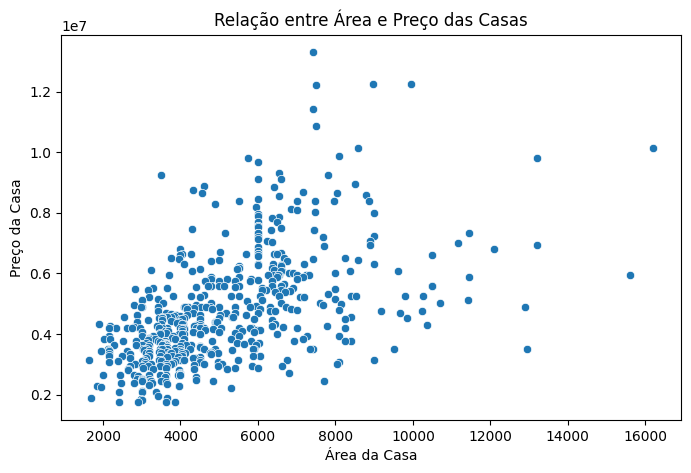

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['area'], y=df['price'])

plt.title('Relação entre Área e Preço das Casas')
plt.xlabel('Área da Casa')
plt.ylabel('Preço da Casa')

plt.show()

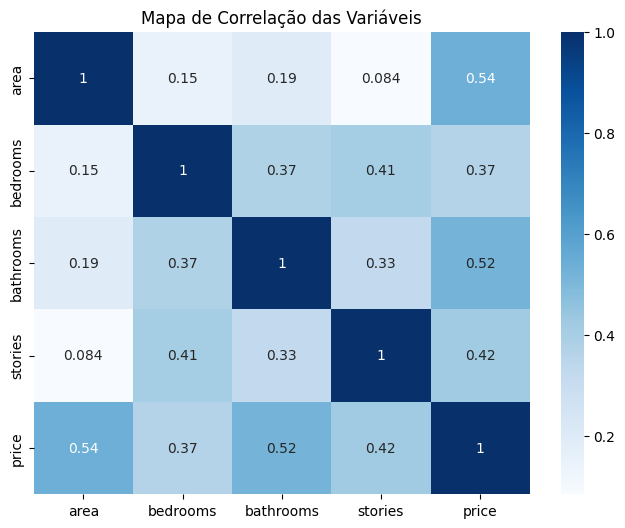

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['area', 'bedrooms', 'bathrooms', 'stories', 'price']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Mapa de Correlação das Variáveis')

plt.show()

> Após feita a plotagem do gráfico de dispersão, foi possível observar uma tendência positiva entre a área da casa e o preço do imóvel.  
Também foi feita a plotagem de um gráfico de calor, e com ele, consegui identificar que as variáveis como quantidade de banheiros, quartos e andares também apresentam correlação positiva com o preço das casas.



#### MACHINE LEARNING - REGRESSÃO LINEAR

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

> Nesta etapa, os dados foram divididos em conjuntos de treino e teste utilizando a função train_test_split.  
Foram utilizados 80% dos dados para treinamento do modelo e 20% para teste, permitindo avaliar o desempenho da regressão linear em dados que não foram utilizados durante o treinamento.
O parâmetro random_state=42 foi utilizado para garantir a reprodutibilidade dos resultados.

In [ ]:
#Criando o modelo de Regressão Linear
modelo = LinearRegression()

modelo.fit(x_train, y_train)

LinearRegression()

In [ ]:
#Previsão
y_pred = modelo.predict(x_test)

In [ ]:
#Avaliação do Modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE(Erro quadrático médio):', mse)
print('R²:', r2)

MSE(Erro quadrático médio): 2457741642022.087
R²: 0.513758534903707


> O MSE, apresentou um valor um pouco alto, mostrando que ainda existe uma diferença considerável entre os valores da previsão do modelo e os valores das casas. mas, isso é até compreensivel, já que apenas usei variáveis númericas para realizar o treinamento.  
> Já o R² apresentou um resultado de quase 51%, e isso mostra que o modelo conseguiu explicar uma boa parte da variação dos preços, com apenas a área da casa, quantidade de banheiros, quantidades de quartos e andares da casa.  
E com isso foi possível perceber uma relação positiva entre as variáveis, mostrando que casas maiores tendem a possuir preços mais altos.

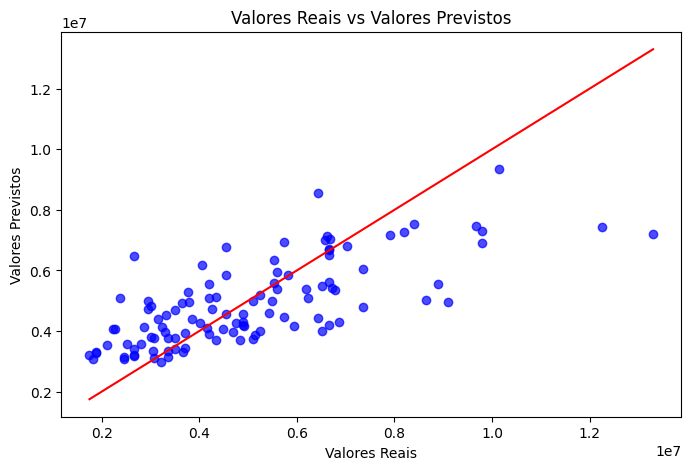

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, color='blue', alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')

plt.title('Valores Reais vs Valores Previstos')

plt.show()

> A linha vermelha representa a previsão ideal do modelo.  
Observando o gráfico, é possível perceber que muitos valores previstos ficaram próximos dos valores reais, mostrando que o modelo conseguiu identificar parte do comportamento dos preços das casas.

### ***CONCLUSÃO***

---

*Utilizando a regressão linear, é possível realizar uma análise da correlação entre área da casa, quantidade de banheiros, quantidade de quartos e quantidade de andares em relação ao preço das casas.  
Os resultados mostram uma relação entre as variáveis, sugerindo que casas com áreas mais amplas podem apresentar preços mais altos e que o tanto de banheiros também influenciam, juntamente com a quantidade de quartos e andares da casa.  
Embora o modelo não forneça uma explicação completa para a variação dos preços, foi possivel identificar uma correlação entre as variáveis utilizadas.*